In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import control as ct
import cvxpy as cp
from scipy.linalg import sqrtm
import mosek
from numba import njit
import time
from Functions._GraphUtils import *

def plot_simulation(results):
    ω_r, ω_g, τ_r, τ_g, τ_gr, φ_m, φ_r, Pg, Pd,Pr, Eg, Ed, D_h,β_h, β_r, t, vtil, u_k, λ, mode,alpha = results

    fig, ax = plt.subplots(2, 1, figsize=(6, 3.5), sharex=True)

    ax[0].plot(t,vtil, label='Vento (m/s)', color='blue')
    ax[0].set_ylabel('Vento (m/s)')
    ax[0].set_xlabel('Tempo (seg)')
    ax[0].legend()
    ax[0].grid(True)

    '''ax[0].plot(t,Pg/1000, label='Potência (kW)', color='green')
    ax[0].plot(t,Pr/1000 , 'r--', label='Nominal')
    ax[0].set_ylabel('Potência (kW)')
    #ax[0].set_ylim(-100, 5200)
    ax[0].legend()
    ax[0].grid(True)

    ax[1].plot(t,Ed/1000, label='Energia Dissipada (Ws)', color='green')
    #ax[2].plot(time_h,hD/1000, label='O.E - Energia Dissipada (Ws)', color='red')
    ax[1].set_ylim(-0.001, 0.02)
    ax[1].set_ylabel('Energia (kWs)')
    ax[1].legend()
    ax[1].grid(True)

    ax[2].plot(t,ω_g, label='Velocidade Angular wg (rad/s)', color='red')
    #ax[3].plot(time_h,wr, label='Velocidade Angular wr (rad/s)', color='blue')
    ax[2].set_ylabel('wg (rad/s)')
    #ax[2].set_ylim(0, 175)
    ax[2].legend()
    ax[2].grid(True)

    ax[3].plot(t,φ_r, label='Pitch-r (graus)', color='black')
    ax[3].plot(t,φ_m, label='Pitch-m (graus)', color='orange')
    ax[3].set_ylabel('Pitch (graus)')
    ax[3].set_ylim(-5, 25)
    ax[3].legend()
    ax[3].grid(True)

    ax[4].plot(t,mode, label='Modo do Controlador (1 ou 2)', color='black')
    ax[4].set_ylabel('Modo')
    ax[4].set_xlabel('Tempo (seg)')
    ax[4].legend()
    ax[4].grid(True)'''

    plt.tight_layout(rect=[0,0,1,1])
    if alpha==0: plt.savefig('Images/Uk_0.png', dpi=500)
    else: plt.savefig('Images/Uk_1.png', dpi=500)
    plt.show()

def solve_lmi_gain(c, Ts, Q=np.diag([1, 2.5e-5]), R=np.array([[100.0]])):
        """
        Calcula o ganho ótimo do observador L usando a solução LMI para o problema LQ
        proposto na Seção 4.4.3 do artigo.

        Args:
            Q (np.array): Matriz de custo do estado (process noise covariance).
            R (np.array): Matriz de custo da medição (measurement noise covariance).
        """
        H = np.diag([1,1]) + Ts * np.array([[0,1],[0,-c]])
        C = np.array([[1,0]])
        n = H.shape[0] # Dimensão do estado (n=2)
        p = C.shape[0] # Dimensão da saída (p=1)

        # ---- Formulação do Problema LMI (Seção 4.4.3) ----
        # 1. Definir as variáveis da LMI
        # P: Matriz de Lyapunov (simétrica, definida positiva)
        P = cp.Variable((n, n), PSD=True)
        # Y: Variável de mudança para L (L = inv(P) * Y^T)
        Y = cp.Variable((p, n))
        # W: Limite superior para a função de custo
        W = cp.Variable((n + p, n + p), symmetric=True)

        # 2. Definir as matrizes de custo estendidas M e N (Equação 56)
        M = np.vstack([sqrtm(Q), np.zeros((p, n))])
        N = np.vstack([np.zeros((n, p)), sqrtm(R)])

        # 3. Definir as restrições (constraints) da LMI
        #constraints = [P >> 1e-16*np.eye(n)] # P deve ser definida positiva
        constraints = [P >> 1e-8]

        # Restrição de estabilidade (Equação 58, adaptada da condição de Lyapunov)
        # Esta é a LMI principal que garante a convergência do erro de estimação.
        lmi_stability = cp.bmat([
            [           (-P+Q), (H.T @ P - C.T @ Y)],
            [(P.T @ H - Y.T @ C),                -P]
        ])
        constraints += [lmi_stability << -1e-8]

        # Restrição da função de custo (Equação 61)
        lmi_cost = cp.bmat([
            [                      W, (M @ P + N @ Y)],
            [(P.T @ M.T + Y.T @ N.T),               P]
        ])
        constraints += [lmi_cost >> 1e-8]
        
        # 4. Definir o problema de otimização (Equação 62)
        # Minimizar o traço de W, que minimiza a função de custo do erro.
        objective = cp.Minimize(cp.trace(W))
        problem = cp.Problem(objective, constraints)

        # 5. Resolver o problema
        problem.solve(solver=cp.MOSEK)
        
        if problem.status not in ["infeasible", "unbounded"]:
            # Calcular o ganho L a partir das variáveis da solução
            # L = (inv(P) * Y^T)
            P_val = P.value
            Y_val = Y.value
            L_val = np.linalg.inv(P_val) @ Y_val.T
            L = (L_val.flatten()).reshape(-1,1)
            #print(f"Ganho L calculado com sucesso: {self.L}")
            
        else:
            print(f"Falha ao resolver a LMI. Status: {problem.status}")
        return H, L, C

def solve_lqr_gain(Q=np.diag([1, 1]), R_=np.array([[1e-5]]), **params):
        """
        Calcula os ganhos ótimos K1 e K2 usando a solução LMI para o problema
        de LQR Robusto descrito na Seção 4.4.2 do artigo.
        
        Args:
            Q (np.array): Matriz de custo do estado (2x2).
            R (np.array): Matriz de custo do controlo (1x1).
        """
        LAMBDA_opt, B_dt,  Rr = params['LAMBDA_opt'], params['B_dt'], params['R']
        vwL, vwU = params['lowerVt'], params['upperVt']
        gamma_min = (B_dt*(vwL**2))*2*LAMBDA_opt/(Rr**2)
        gamma_max = (B_dt*(vwU**2))*2*LAMBDA_opt/(Rr**2)

        n = 2 # Dimensão do estado x_k = [u_{k-1}, z_k]
        m = 1 # Dimensão da entrada u_k

        # --- Formulação do Problema LMI (Seção 4.4.2) ----
        # 1. Definir as variáveis da LMI
        P = cp.Variable((n, n), PSD=True)
        Y = cp.Variable((m, n))
        W = cp.Variable((n + m, n + m), symmetric=True)

        # 2. Definir as matrizes de custo estendidas M e N (Equação 39)
        M = np.vstack([sqrtm(Q), np.zeros((m, n))])
        N = np.vstack([np.zeros((n, m)), sqrtm(R_)])

        # 3. O sistema politópico tem 2 vértices (extremos de ~γ)
        # Vértice 1: Corresponde a gamma_min
        # Vértice 2: Corresponde a gamma_max
        A_vertices = [
            np.array([[0, 0], [gamma_min, 1]]),
            np.array([[0, 0], [gamma_max, 1]])
        ]
        B = np.array([[1], [0]])

        # 4. Definir as restrições da LMI para TODOS os vértices
        constraints = [P >> 1e-8] # P deve ser definida positiva

        for A in A_vertices:
            # Restrição de estabilidade (Equação 44)
            lmi_stability = cp.bmat([
                [               (-P+Q), (A @ P - B @ Y)],
                [(P @ A.T - Y.T @ B.T),              -P]
            ])
            constraints += [lmi_stability << -1e-8]

        # Restrição da função de custo (Equação 47)
        lmi_cost = cp.bmat([
            [                    W, (M @ P + N @ Y)],
            [(P @ M.T + Y.T @ N.T),               P]
        ])
        constraints += [lmi_cost >> 1e-8]
        
        # 5. Definir e resolver o problema de otimização
        objective = cp.Minimize(cp.trace(W))
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.MOSEK,verbose=False)

        # 6. Calcular os ganhos K a partir da solução
        if problem.status in ["infeasible", "unbounded"] or P.value is None:
            print(f"Falha ao resolver a LMI do LQR. Status: {problem.status}")
            return None

        P_val = P.value
        Y_val = Y.value
        
        # K = Y * inv(P)
        K_val = Y_val @ np.linalg.inv(P_val)
        K = (K_val.flatten())
        return K
        
# ==========================================
# 1. Funções Compiladas (Numba JIT)
# ==========================================

@njit(fastmath=True)
def get_coeff(lambda_val, phi_val, tsr_axis, pitch_axis, data_table):
    """
    Substitui Cp_calc e Cq_calc.
    Realiza busca rápida na tabela pré-carregada.
    """
    # Encontrar índice mais próximo para TSR (Lambda)
    # Assume que tsr_axis está ordenado
    idx1 = np.argmin(np.abs(tsr_axis - lambda_val))
    
    # Encontrar índice mais próximo para Pitch (Phi)
    idx2 = np.argmin(np.abs(pitch_axis - phi_val))
    
    return data_table[idx1, idx2]

@njit(fastmath=True)
def simulation_core(N_steps, v_wind,
                    hawt_Ad, hawt_Bd, hawt_X_init,
                    gtc_Ad, gtc_Bd, gtc_Cd, gtc_Dd,
                    pac_Ad, pac_Bd, pac_Cd, pac_Dd,
                    dso_Ad, dso_Bd, fbc_Ad, fbc_Bd,
                    R, RHO, Area, N_g, PI, P_r, D_max, t_ref,
                    lambda_opt, eta_gc, omega_nom, omega_var,
                    k_p, k_i, B_dt, Ts, Ts_RUL, vwL, vwU,
                    tsr_axis, pitch_axis, cp_table, cq_table, K_gain, alpha = 0):
    
    t_ref = 2.5*3600*100
    print('t_ref',t_ref)


    # --- Pré-alocação de Arrays (Velocidade Extrema) ---
    w_r_hist = np.zeros(N_steps)
    w_g_hist = np.zeros(N_steps)
    theta_s_hist = np.zeros(N_steps)
    tau_r_hist = np.zeros(N_steps)
    tau_g_hist = np.zeros(N_steps)
    tau_gr_hist = np.zeros(N_steps)
    phi_m_hist = np.zeros(N_steps)
    phi_r_hist = np.zeros(N_steps)
    P_g_hist = np.zeros(N_steps)
    P_d_hist = np.zeros(N_steps)
    P_r_hist = np.zeros(N_steps)
    E_g_hist = np.zeros(N_steps)
    E_d_hist = np.zeros(N_steps)
    hD_hist = np.zeros(N_steps)
    hB_hist = np.zeros(N_steps)
    Br_hist = np.zeros(N_steps)
    time_hist = np.zeros(N_steps)
    u_k_hist = np.zeros(N_steps)
    lambda_hist = np.zeros(N_steps)
    vtil_hist = np.zeros(N_steps)
    mode_hist = np.zeros(N_steps) # 1.0 para mode1, 2.0 para mode2
    
    # --- Inicialização de Estados ---
    # HAWT: [wr, wg, theta]
    x_hawt = hawt_X_init.astype(np.float64).copy()
    
    # GTC: [estado]
    x_gtc = np.array([0.0])
    
    # PAC: [estado1, estado2]
    x_pac = np.array([0.0, 0.0])

    # DSO: [estado1, estado2]
    x_dso = np.array([1e-5, 1e-5])

    # DSO: [estado1, estado2]
    x_fbc = np.array([1e-5, 1e-5]).reshape(-1,1)
    
    z_k = 0
    u_k = 0
    phi_m = 0
    # Variáveis de Controle
    phi_ref_prev = 0.0
    error_prev = 0.0
    current_mode = 1 # Começa no modo 1
    
    for k in range(N_steps):
        
        v = v_wind[k]
        
        # Leitura dos estados atuais do HAWT
        w_r = x_hawt[0]
        w_g = x_hawt[1]
        theta_s = x_hawt[2]
        
        # --- 1. Power Controller Logic (PWC) ---
        epsilon = w_g - omega_nom
        
        tau_gr = 0.0
        phi_ref = 0.0
        
        if current_mode == 1:
            # Mode 1: Maximização de Cp (Torque quadrático)
            # u_k assumido 0
            lambda_calc = lambda_opt + u_k
            
            # Busca Cp na tabela (Pitch = 0)
            C_p = get_coeff(lambda_calc, 0.0, tsr_axis, pitch_axis, cp_table)
            
            K_opt = RHO * Area * (R**3) * C_p / (2 * (lambda_calc**3))
            tau_gr = K_opt * (((w_g**2) / (N_g**3)))
            
            phi_ref = 0.0
            phi_ref_prev = 0.0 # Manter rastreio
            error_prev = epsilon # Atualizar erro para transição suave


        else: # Mode 2
            # Mode 2: Controle de Potência/Velocidade via Pitch
            # Torque mantém potência constante
            derating_factor = 1.0 - (alpha * u_k)
            derating_factor=(lambda_opt/(lambda_opt+u_k))
            #current_P_ref = P_r * derating_factor
            
            if w_g > 0.0001:
                #tau_gr = P_r / (eta_gc * w_g)
                tau_gr = P_r / (eta_gc * w_g )
            else:
                tau_gr = 0.0
                
            # PI Controller para Pitch (Algoritmo de Velocidade/Incremental)
            # phi_ref = phi_prev + kp*e + (ki*Ts - kp)*e_prev
            delta_u = k_p * epsilon + (k_i * Ts - k_p) * error_prev
            phi_ref = phi_ref_prev + delta_u
            
            # Saturação do Pitch (0 a 90 graus)
            #if phi_ref < 0: phi_ref = 0
            #if phi_ref > 90: phi_ref = 90

            if phi_ref < -2: phi_ref = -2
            if phi_ref > 95: phi_ref = 95
            
            # Atualiza memórias do controlador
            phi_ref_prev = phi_ref
            error_prev = epsilon

        # --- 2. Generator Torque Converter (GTC) ---
        u_gtc = np.array([tau_gr * 1])
        # Y = C*x + D*u
        y_gtc = (gtc_Cd @ x_gtc + gtc_Dd @ u_gtc)[0]
        tau_g_applied = y_gtc
        
        P_g = eta_gc * w_g * tau_g_applied 
        P_d = B_dt * ((w_r-(w_g/N_g))**2)

        if k < 1:
            E_g = P_g*Ts
            E_d = P_d*Ts
        else:
            E_g = E_g_hist[k-1] + P_g*Ts
            E_d = E_d_hist[k-1] + P_d*Ts
        
        # Atualiza estado GTC: X_new = A*x + B*u
        x_gtc = gtc_Ad @ x_gtc + gtc_Bd @ u_gtc
        
        # --- 3. Pitch Angle Controller (PAC) ---
        u_pac = np.array([phi_ref])
        y_pac = (pac_Cd @ x_pac + pac_Dd @ u_pac)[0]
        phi_m = y_pac
        
        # Atualiza estado PAC
        x_pac = pac_Ad @ x_pac + pac_Bd @ u_pac
        
        # --- 4. Aerodynamic Model (ADM) ---
        if v < 0.1:
            lamb = 0.0
        else:
            lamb = w_r * R / v
            
        C_q = get_coeff(lamb, phi_m, tsr_axis, pitch_axis, cq_table)
        tau_r = RHO * PI * (R**3) * C_q * (v**2) / 2.0
        
        # --- 5. HAWT Dynamics (Plant) ---
        u_hawt = np.array([tau_r, tau_g_applied])
        
        # Atualiza estado HAWT (w_r, w_g, theta)
        x_hawt = hawt_Ad @ x_hawt + hawt_Bd @ u_hawt

        D_max = 50
        if  k%1000==0:
            
            # --- 7. Reference Converter ---
            RUL_ref = (t_ref - (k))
            #print('RUL_ref:',RUL_ref, k)
            BETA_ref = (D_max - x_dso[0])/RUL_ref

            # --- 6. Degradation State Observer (DSO) ---
            x_dso = dso_Ad @ x_dso + dso_Bd @ np.array([E_d])
            dD, dBETA = x_dso[0], x_dso[1]
            
            # --- 8. Feedback Controller ---
            """ np.random.seed(k)
            vtil = np.random.normal(loc=2, scale=0.5, size=1)
            vtil = np.clip(vtil, vwL, vwU)[0]
            gamma = B_dt*(vtil**2)*2*lambda_opt/(R**2)
            fbc_Ad[1][0] = gamma
            
            #delta_beta  = gamma * x_fbc[0]
            #print( gamma)
            u_fbc = (-K_gain @ x_fbc)[0]
            y_ = np.array([1,0]).reshape(-1,1)
            #print(u_fbc*np.array([[1],[0]]))
            x_fbc = (fbc_Ad @ x_fbc + u_fbc*np.array([[1],[0]])) # + np.array([0,-1]) * delta_beta
            print(x_fbc) """
            z_k = z_k + (dBETA-BETA_ref)
            u_k = -K_gain[0]*u_k - K_gain[1]*z_k
        # Hysteresis simples para troca de modo (exemplo)
        # Se passar da velocidade nominal + tolerância, vai para Mode 2
        if current_mode == 1 and w_g >= (omega_nom) or P_g >= P_r:
            current_mode = 2
        elif current_mode == 2 and w_g < (omega_nom - omega_var):
            current_mode = 1
            phi_ref_prev = 0.0 # Resetar pitch ao voltar para torque control
            #u_k =0

        if alpha == 0: u_k = 0

        # --- Salvar Histórico ---
        w_r_hist[k] = w_r
        w_g_hist[k] = w_g
        theta_s_hist[k] = theta_s
        tau_r_hist[k] = tau_r
        tau_g_hist[k] = tau_g_applied
        tau_gr_hist[k] = tau_gr
        phi_m_hist[k] = phi_m
        phi_r_hist[k] = phi_ref
        P_g_hist[k] = P_g
        P_d_hist[k] = P_d
        P_r_hist[k] = P_r
        E_g_hist[k] = E_g
        E_d_hist[k] = E_d
        hD_hist[k] = x_dso[0]
        hB_hist[k] = x_dso[1]
        Br_hist[k] = BETA_ref 
        time_hist[k] = k*Ts
        lambda_hist[k] = lambda_calc
        u_k_hist[k] = u_k
        vtil_hist[k] = v
        mode_hist[k] = current_mode

        #if E_d >= D_max: 
        #    break

        
    #print('k',k)
    #print('Ts:',Ts)
    return w_r_hist, w_g_hist, tau_r_hist, tau_g_hist,tau_gr_hist, phi_m_hist, phi_r_hist, P_g_hist, P_d_hist,P_r_hist, E_g_hist, E_d_hist, hD_hist, hB_hist, Br_hist, time_hist, vtil_hist, u_k_hist, lambda_hist, mode_hist, alpha

# ==========================================
# 2. Preparação de Dados (Python Puro)
# ==========================================

def prepare_simulation():
    # --- Carregar CSVs ---
    #print("Carregando tabelas...")
    try:
        # Tente carregar seus arquivos originais
        params_df = pd.read_csv(r'params2.csv')
        params = dict(zip(params_df['Parameter'], params_df['Value']))
        #print('params:',params)
        #path1 = r'Datasets/WindSpeed_V1.csv'
        #path = r'Datasets/WindSpeedML_v1.csv'

        paths = [r'Datasets/WindSpeed_V1.csv', r'Datasets/WindSpeedML_v1.csv', r'Datasets/WindSpeedML_v2.csv']
        path = paths[2]

        df_wind = pd.read_csv(path)
        v = df_wind.iloc[:,0].values *1
        df_cp = pd.read_csv(r'Cp_R0.csv')
        df_cq = pd.read_csv(r'Cq_R0.csv')
        
        # Preparar Eixos e Tabelas para Numba
        # Assumindo estrutura do seu código original (Coluna 0 = TSR, Resto = Coeficientes por Pitch)
        tsr_axis = df_cp.iloc[:, 0].values.astype(np.float64)
        #tsr_axis = df_cp.iloc[1:, 0].values.astype(np.float64)
        
        # Ângulos hardcoded do seu script original
        angles = np.array([-2,-1.5,-1,-0.75,-0.5,-0.25,0,0.25,0.5,0.75,1,1.5,2,3,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95]).astype(np.float64)
        #angles = df_cp.iloc[0,1:].values

        # Extrair matrizes de dados (dropando coluna TSR)
        cp_table = df_cp.iloc[:, 1:].values.astype(np.float64)
        cq_table = df_cq.iloc[:, 1:].values.astype(np.float64)
        #cp_table = df_cp.iloc[1:, 1:].values.astype(np.float64)
        #cq_table = df_cq.iloc[1:, 1:].values.astype(np.float64)
        
    except FileNotFoundError:
        print("AVISO: Arquivos não encontrados. Usando dados fictícios para teste.")
        # Dados Dummy para o código rodar se você copiar e colar agora
        params = {
            'Area': 100, 'B_dt': 1, 'B_r': 1, 'B_g': 1, 'CP_max': 0.45, 'ETA_dt': 0.9, 'ETA_gc': 0.9,
            'J_r': 100, 'J_g': 10, 'K_dt': 1000, 'k_i': 1.0, 'k_p': 0.1, 'LAMBDA_opt': 8, 'N_g': 90,
            'OMEGA_n': 1, 'OMEGA_nom': 100, 'OMEGA_var': 1, 'PHI_opt': 0, 'P_r': 1000, 'PI': np.pi,
            'R': 40, 'RHO': 1.225, 'ALPHA_gc': 10, 'ZETA': 0.7
        }
        v = np.linspace(5, 15, 1000) # Vento rampa
        tsr_axis = np.linspace(0, 20, 100)
        angles = np.linspace(-2, 95, 33)
        cp_table = np.random.rand(100, 33) * 0.4
        cq_table = np.random.rand(100, 33) * 0.05

    Ts = 0.01 # Seu Time Step
    Ts = params['T_s']
    # --- Construção das Matrizes (Control Library) ---
    
    # 1. HAWT Matrices
    B_dt, B_r, B_g = params['B_dt'], params['B_r'], params['B_g']
    J_r, J_g, N_g = params['J_r'], params['J_g'], params['N_g']
    K_dt, ETA_dt = params['K_dt'], params['ETA_dt']
    
    A_hawt = np.array([
        [-(B_dt+B_r)/J_r, B_dt/(N_g*J_r), -K_dt/J_r],
        [(B_dt*ETA_dt)/(N_g*J_g), -(((B_dt*ETA_dt)/(N_g**2))+B_g)*(1/J_g), (K_dt*ETA_dt)/(N_g*J_g)],
        [1, -1/N_g, 0]
    ])
    B_hawt = np.array([
        [1/J_r, 0],
        [0, -1/J_g],
        [0, 0]
    ])
    
    sys_hawt = ct.c2d(ct.ss(A_hawt, B_hawt, np.eye(3), np.zeros((3,2))), Ts, method='zoh')
    
    # 2. GTC Matrices
    alpha_gc = params['ALPHA_gc']
    sys_gtc = ct.c2d(ct.ss(ct.tf([alpha_gc], [1, alpha_gc])), Ts, method='zoh')
    
    # 3. PAC Matrices
    omega_n, zeta = params['OMEGA_n'], params['ZETA']
    sys_pac = ct.c2d(ct.ss(ct.tf([omega_n**2], [1, 2*omega_n*zeta, omega_n**2])), Ts, method='zoh')

    # 4. Degradation State Observer
    Ts_RUL = params['Ts_RUL']
    c=0.01
    H, L, C = solve_lmi_gain(c,Ts_RUL, Q=np.diag([1, 2.5e-5]), R=np.array([[100.0]]))
    A_dso = (H - L@C)
    B_dso = L
    sys_dso = ct.ss(A_dso, B_dso, np.zeros_like(A_dso), np.zeros_like(B_dso), Ts_RUL) #VERIFICAR Ts#
   
    # 5. Feedback Controller
    K_gain = solve_lqr_gain(**params)
    A_fbc = np.array([[0,0],[1,1]])
    B_fbc = np.array([[1],[0]]) @ np.array([-K_gain])
    sys_fbc = ct.ss(A_fbc,B_fbc,np.zeros_like(A_fbc), np.zeros_like(B_fbc), Ts_RUL) #VERIFICAR Ts#

    # Retorna tudo compactado para passar ao Numba
    # É crucial usar np.ascontiguousarray para performance máxima no Numba
    matrices = {
        'h_Ad': np.ascontiguousarray(sys_hawt.A), 'h_Bd': np.ascontiguousarray(sys_hawt.B),
        'g_Ad': np.ascontiguousarray(sys_gtc.A), 'g_Bd': np.ascontiguousarray(sys_gtc.B), 'g_Cd': np.ascontiguousarray(sys_gtc.C), 'g_Dd': np.ascontiguousarray(sys_gtc.D),
        'p_Ad': np.ascontiguousarray(sys_pac.A), 'p_Bd': np.ascontiguousarray(sys_pac.B), 'p_Cd': np.ascontiguousarray(sys_pac.C), 'p_Dd': np.ascontiguousarray(sys_pac.D),
        's_Ad': np.ascontiguousarray(sys_dso.A), 's_Bd': np.ascontiguousarray(sys_dso.B),
        'f_Ad': np.ascontiguousarray(sys_fbc.A), 'f_Bd': np.ascontiguousarray(sys_fbc.B),
    }
    
    return params, v, tsr_axis, angles, cp_table, cq_table, K_gain, matrices

def simulation_results(alpha):
    params, v_wind, tsr_axis, pitch_axis, cp_table, cq_table, K_gain, mats = prepare_simulation()
    Ts = 0.01
    N_steps = len(v_wind[:])
    hawt_X_init = np.array([1, 1*params['N_g'], 0])

    results = simulation_core(N_steps, v_wind,
        mats['h_Ad'], mats['h_Bd'], hawt_X_init,
        mats['g_Ad'], mats['g_Bd'], mats['g_Cd'], mats['g_Dd'],
        mats['p_Ad'], mats['p_Bd'], mats['p_Cd'], mats['p_Dd'],
        mats['s_Ad'], mats['s_Bd'], mats['f_Ad'], mats['f_Bd'],
        params['R'], params['RHO'], params['Area'], params['N_g'], params['PI'],
        params['P_r'],params['D_max'],params['T_desired'],
        params['LAMBDA_opt'], params['ETA_gc'], params['OMEGA_nom'], params['OMEGA_var'],
        params['k_p'], params['k_i'], params['B_dt'], params['T_s'], params['Ts_RUL'], params['lowerVt'], params['upperVt'],
        tsr_axis, pitch_axis, cp_table, cq_table, K_gain,alpha)
    
    return results


In [2]:
uk_,Pg_,Pd_,Ed_,Eg_,τr_,τg_ = [[] for i  in range(7)]
alphas = [i*0.05 for i in range(2)]
for alpha in alphas[0:2]:
    results = simulation_results(alpha=alpha)
    ω_r, ω_g, τ_r, τ_g, τ_gr, φ_m, φ_r, Pg, Pd,Pr, Eg, Ed, D_h,β_h, β_r, t, vtil, u_k, λ, mode,alpha = results
    uk_.append(u_k)
    Pg_.append(Pg)
    Pd_.append(Pd)
    Ed_.append(Ed)
    Eg_.append(Eg)
    τr_.append(τ_r)
    τg_.append(τ_g)

t_ref 413000.69999999995
t_ref 413000.69999999995


In [ ]:
results1 = simulation_results(alpha=0)

ω_r, ω_g, τ_r, τ_g, τ_gr, φ_m, φ_r, Pg1, Pd1,Pr, Eg1, Ed1, D_h,β_h, β_r, t, vtil, u_k, λ, mode,alpha = results1
plot_simulation(results1)


t_ref 900000.0


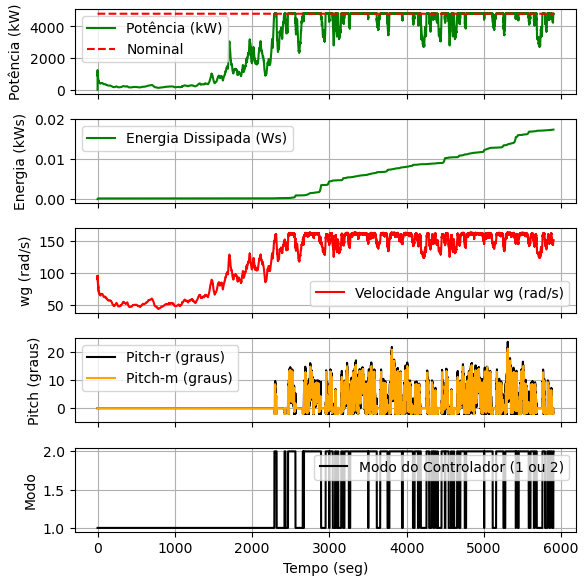

In [79]:
results2 = simulation_results(alpha=1)

ω_r, ω_g, τ_r, τ_g, τ_gr, φ_m, φ_r, Pg2, Pd2,Pr, Eg2, Ed2, D_h,β_h, β_r, t, vtil, u_k, λ, mode,alpha = results2
plot_simulation(results2)

C:\Users\claud\AppData\Local\Temp\ipykernel_29228\4036589307.py:43: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



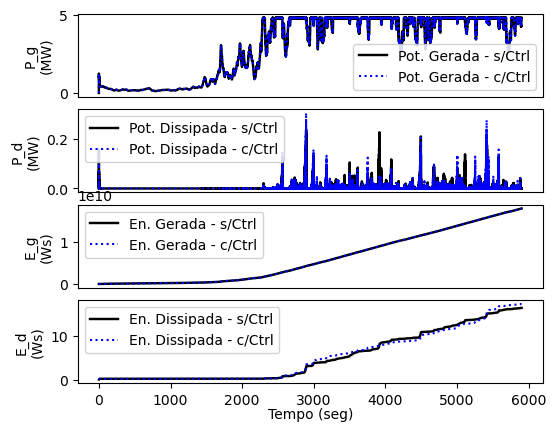

In [80]:
compare_simulation(results1,results2)

In [63]:
def compare_simulation(results1,results2,w=6,h=4.8,flbl=7,flgnd=7,ftcks=7):
    ω_r1, ω_g1, τ_r1, τ_g1, τ_gr1, φ_m1, φ_r1, Pg1, Pd1,Pr1, Eg1, Ed1, D_h1,β_h1, β_r1, t1, vtil1, u_k1, λ1, mode1,u_k_fixed1 = results1
    ω_r2, ω_g2, τ_r2, τ_g2, τ_gr2, φ_m2, φ_r2, Pg2, Pd2,Pr2, Eg2, Ed2, D_h2,β_h2, β_r2, t2, vtil2, u_k2, λ2, mode2,u_k_fixed2 = results2
    t=t1
    ToPlot1 = [Pg1,Pd1,Eg1,Ed1]
    ToPlot2 = [Pg2,Pd2,Eg2,Ed2]
    names = ['P_g\n(MW) - S','P_d\n(MW) - S','E_g\n(Ws) - S','E_d\n(Ws) - S','Velocidade \n Angular (rad/s) - S'
             ,'Pitch-r (graus) - S','Pitch-M (graus) - S','Modo do \n Controlador - S']
    names2 = ['Pot. Gerada','Pot. Dissipada','En. Gerada','En. Dissipada']
    nrows = len(ToPlot1)
    #fig = plt.figure(figsize=(w, h))
    #fig.subplots_adjust(left=0.04, right=0.98, top=0.88, bottom=0.12,wspace=0.12, hspace=0.15)

    fig = plt.figure(figsize=(w, h))

    gs = fig.add_gridspec(nrows=nrows, ncols=2,
                            #height_ratios=[1, 1, 1, 1, 1],
                            hspace=0.15
                            )

    axes = []
    for i in range(4):
        axes.append(fig.add_subplot(gs[i, :]) )

    for i,ax in enumerate(axes):
        y1,y2 = ToPlot1[i], ToPlot2[i]
        if i == 0: y1,y2 = ToPlot1[i]/1e6, ToPlot2[i]/1e6
        ax.plot(t,y1, label=f'{names2[i]} - s/Ctrl',color='black',linewidth=1.75)
        ax.plot(t,y2, label=f'{names2[i]} - c/Ctrl',linestyle=':',color='blue',linewidth=1.5)
        ax.set_xlabel(f"Tempo (seg)",labelpad=0)
        ax.set_ylabel(f"{names[i][:-4]}")
        #ax.tick_params(labelsize=ftcks,axis='x',colors='1',)
        #ax.tick_params(labelsize=0.1,axis='y',colors='1',)
        if i ==0: ax.legend( framealpha=0.85)
        if i < nrows-1:
            ax.set_xlabel('')
            ax.xaxis.set_visible(False)
            
        if i == 5: 
            ax.set_ylim(0.5, 2.5)
            ax.set_yticks([1,2])
        ax.legend( framealpha=0.85)
    plt.tight_layout(rect=[0,0,1,1])
    plt.savefig('Images/Uk_c.png', dpi=500)
    plt.show()



NameError: name 'N_steps' is not defined

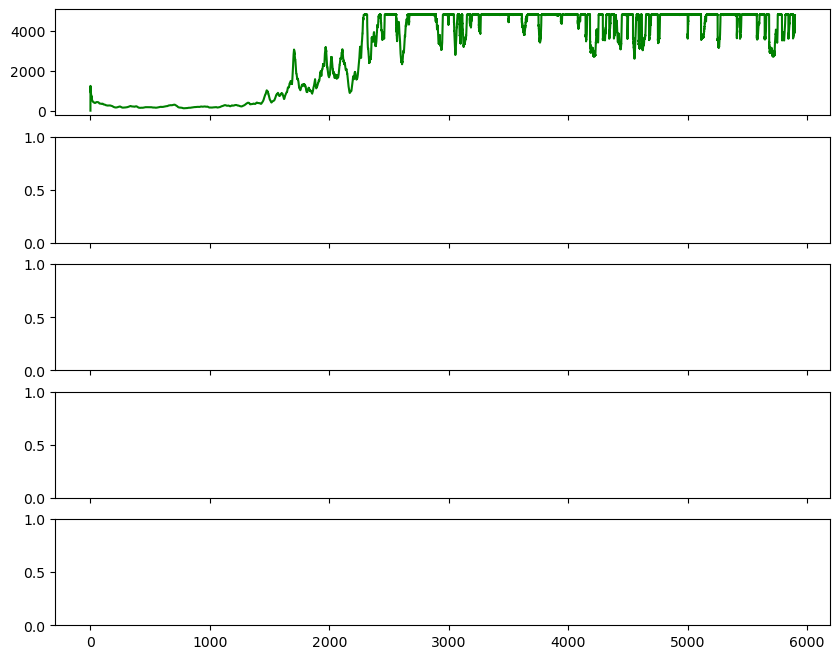

In [3]:
fig, ax = plt.subplots(5, 1, figsize=(10, 8), sharex=True)

'''ax[0].plot(t,v_wind, label='Vento (m/s)', color='blue')
ax[0].set_ylabel('Vento (m/s)')
ax[0].legend()
ax[0].grid(True)'''

ax[0].plot(t,Pg/1000, label='Potência (kW)', color='green')
ax[0].plot(t, [params['P_r']/1000 for i in range(N_steps)], 'r--', label='Nominal')
ax[0].set_ylabel('Potência (kW)')
#ax[0].set_ylim(-100, 5200)
ax[0].legend()
ax[0].grid(True)

ax[1].plot(t,Ed/1000, label='Energia Dissipada (Ws)', color='green')
#ax[2].plot(time_h,hD/1000, label='O.E - Energia Dissipada (Ws)', color='red')
#ax[1].set_ylim(-0.001, 0.02)
ax[1].set_ylabel('Energia (kWs)')
ax[1].legend()
ax[1].grid(True)

ax[2].plot(t,ω_g, label='Velocidade Angular wg (rad/s)', color='red')
#ax[3].plot(time_h,wr, label='Velocidade Angular wr (rad/s)', color='blue')
ax[2].set_ylabel('wg (rad/s)')
#ax[2].set_ylim(0, 175)
ax[2].legend()
ax[2].grid(True)

ax[3].plot(t,φ_r, label='Pitch-r (graus)', color='black')
ax[3].plot(t,φ_m, label='Pitch-m (graus)', color='orange')
ax[3].set_ylabel('Pitch (graus)')
ax[3].set_ylim(-5, 25)
ax[3].legend()
ax[3].grid(True)

ax[4].plot(t,mode, label='Modo do Controlador (1 ou 2)', color='black')
ax[4].set_ylabel('Modo')
ax[4].set_xlabel('Tempo (seg)')
ax[4].legend()
ax[4].grid(True)

plt.tight_layout(rect=[0,0,1,1])
if u_k_fixed: plt.savefig('Images/Uk_0.png', dpi=500)
else: plt.savefig('Images/Uk_1.png', dpi=500)
plt.show()